In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'ETT')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints''time_series', 'real', 'ETT')
OUT_PATH = os.path.join(CURRENT_DIR, 'out' 'time_series', 'real', 'ETT')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [4]:
df_data = pd.read_csv(os.path.join(DATA_PATH, 'ETTh1.csv'))
df_data

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904000
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044000
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271000
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778000


In [5]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
HUFL,17420.0,7.375141,7.067744,-22.705999,5.827,8.774,11.788,23.643999
HULL,17420.0,2.242242,2.042342,-4.756000,0.737,2.210,3.684,10.114000
MUFL,17420.0,4.300239,6.826978,-25.087999,3.296,5.970,8.635,17.341000
MULL,17420.0,0.881568,1.809293,-5.934000,-0.284,0.959,2.203,7.747000
LUFL,17420.0,3.066062,1.164506,-1.188000,2.315,2.833,3.625,8.498000
LULL,17420.0,0.856932,0.599552,-1.371000,0.670,0.975,1.218,3.046000
OT,17420.0,13.324672,8.566946,-4.080000,6.964,11.396,18.079,46.007000


In [6]:
df_data['date'] = pd.to_datetime(df_data['date'])

In [7]:
unique_values = df_data.nunique()
unique_values_df = pd.DataFrame(
    data={
        'variables': df_data.columns,
        'N. unique values': [unique_values[key] for key in unique_values.keys()],
        '% unique values': [(unique_values[key]/df_data.shape[0])*100 for key in unique_values.keys()],
        # 'Unique values': [unique_values[key] for key in unique_values.keys()]
    }
)
unique_values_df.set_index('variables', inplace=True)
unique_values_df

,N. unique values,% unique values
variables,,
date,17420,100.000000
HUFL,613,3.518944
HULL,200,1.148106
MUFL,1031,5.918485
MULL,314,1.802526
LUFL,236,1.354765
LULL,126,0.723307
OT,669,3.840413


In [8]:
df_data.isna().sum()

date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

In [9]:
df_data.duplicated().sum()

0

In [10]:
date_diffs = df_data.index.diff().dropna()
date_diffs.value_counts()

1.0    17419
Name: count, dtype: int64

In [11]:
df_data.set_index('date', inplace=True)

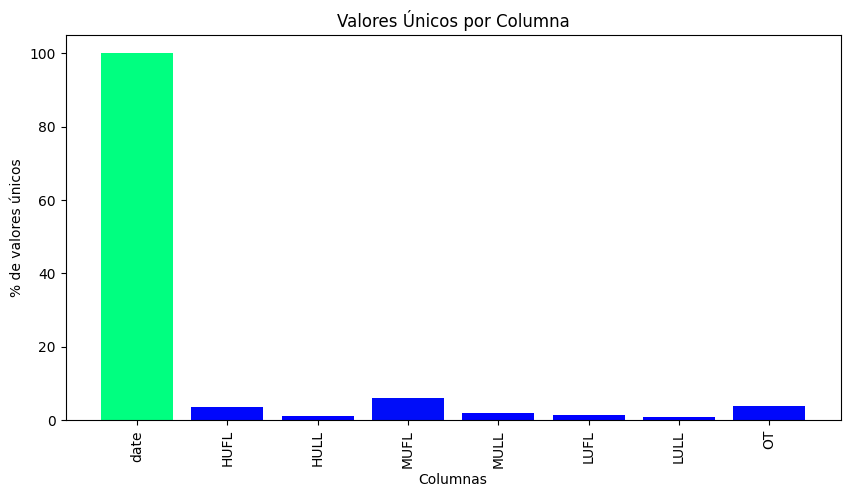

In [12]:
unique_values_perc = unique_values_df['% unique values']
norm = plt.Normalize(vmin=unique_values_perc.min(), vmax=unique_values_perc.max())  # Normalización de los datos
cmap = plt.get_cmap("winter")

plt.figure(figsize=(10, 5))
plt.bar(unique_values_df.index, unique_values_perc, color=cmap(norm(unique_values_perc)))

plt.xlabel("Columnas")
plt.ylabel("% de valores únicos")
plt.title("Valores Únicos por Columna")
plt.xticks(rotation=90)

plt.show()

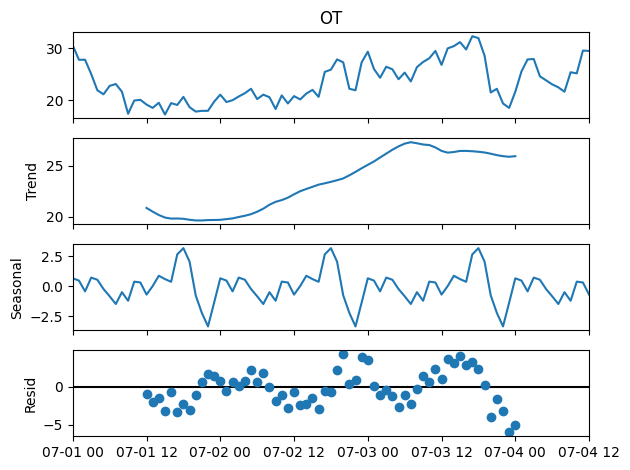

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(df_data['OT'][:85], model="additive")
decomposition.plot()
plt.show()

In [15]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean_h1.parquet'
    ),
    index=True
)

In [5]:
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean_h1.parquet'
    )
)

df_data.rename(columns={"OT": "y"}, inplace=True)
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)